# Actividad para la casa: Análisis de datos usando métodos de ciencia de datos

**Asignatura:** Taller de Aplicaciones  
**Estudiante:** Marisol Alejandra Mera Zumelzu  
**Dataset:** Bank Marketing  

## Problema de negocio

El banco realiza campañas telefónicas para ofrecer depósitos a plazo. Sin embargo, contactar a todos los clientes genera costos operacionales y una baja eficiencia comercial. Por ello, se busca utilizar técnicas de ciencia de datos para segmentar clientes, predecir la aceptación de la oferta y descubrir patrones que apoyen la toma de decisiones comerciales.

In [1]:
!pip install mlxtend

In [2]:
#--- Importar Librerias---

import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score, davies_bouldin_score

from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score

## 1.-Carga de datos

In [3]:
import pandas as pd

df = pd.read_csv("banking.csv")

## 2.- Revisión inicial

In [4]:
df.shape

(41188, 21)

In [5]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 41188 entries, 0 to 41187
Data columns (total 21 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   age             41188 non-null  int64  
 1   job             41188 non-null  str    
 2   marital         41188 non-null  str    
 3   education       41188 non-null  str    
 4   default         41188 non-null  str    
 5   housing         41188 non-null  str    
 6   loan            41188 non-null  str    
 7   contact         41188 non-null  str    
 8   month           41188 non-null  str    
 9   day_of_week     41188 non-null  str    
 10  duration        41188 non-null  int64  
 11  campaign        41188 non-null  int64  
 12  pdays           41188 non-null  int64  
 13  previous        41188 non-null  int64  
 14  poutcome        41188 non-null  str    
 15  emp_var_rate    41188 non-null  float64
 16  cons_price_idx  41188 non-null  float64
 17  cons_conf_idx   41188 non-null  float64
 1

In [6]:
df.describe(include="all")

,age,job,marital,education,default,housing,loan,contact,month,day_of_week,...,campaign,pdays,previous,poutcome,emp_var_rate,cons_price_idx,cons_conf_idx,euribor3m,nr_employed,y
count,41188.00000,41188,41188,41188,41188,41188,41188,41188,41188,41188,...,41188.000000,41188.000000,41188.000000,41188,41188.000000,41188.000000,41188.000000,41188.000000,41188.000000,41188.000000
unique,NaN,12,4,8,3,3,3,2,10,5,...,NaN,NaN,NaN,3,NaN,NaN,NaN,NaN,NaN,NaN
top,NaN,admin.,married,university.degree,no,yes,no,cellular,may,thu,...,NaN,NaN,NaN,nonexistent,NaN,NaN,NaN,NaN,NaN,NaN
freq,NaN,10422,24928,12168,32588,21576,33950,26144,13769,8623,...,NaN,NaN,NaN,35563,NaN,NaN,NaN,NaN,NaN,NaN
mean,40.02406,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,2.567593,962.475454,0.172963,NaN,0.081886,93.575664,-40.502600,3.621291,5167.035911,0.112654
std,10.42125,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,2.770014,186.910907,0.494901,NaN,1.570960,0.578840,4.628198,1.734447,72.251528,0.316173
min,17.00000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,1.000000,0.000000,0.000000,NaN,-3.400000,92.201000,-50.800000,0.634000,4963.600000,0.000000
25%,32.00000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,1.000000,999.000000,0.000000,NaN,-1.800000,93.075000,-42.700000,1.344000,5099.100000,0.000000
50%,38.00000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,2.000000,999.000000,0.000000,NaN,1.100000,93.749000,-41.800000,4.857000,5191.000000,0.000000
75%,47.00000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,3.000000,999.000000,0.000000,NaN,1.400000,93.994000,-36.400000,4.961000,5228.100000,0.000000


In [7]:
df.isnull().sum()

age               0
job               0
marital           0
education         0
default           0
housing           0
loan              0
contact           0
month             0
day_of_week       0
duration          0
campaign          0
pdays             0
previous          0
poutcome          0
emp_var_rate      0
cons_price_idx    0
cons_conf_idx     0
euribor3m         0
nr_employed       0
y                 0
dtype: int64

## Comprensión inicial de los datos
El dataset Bank Marketing contiene 41.188 registros de clientes contactados en campañas de marketing telefónico de una institución bancaria. El objetivo es analizar las características de los clientes y determinar los factores asociados a la aceptación de depósitos a plazo.

El conjunto de datos incluye variables demográficas (edad, educación, estado civil), financieras (créditos, hipotecas), de contacto (tipo de contacto, mes de campaña) y variables económicas (euribor, tasa de empleo, índice de precios).

La variable objetivo corresponde a y, que indica si el cliente aceptó ("yes") o rechazó ("no") la oferta de depósito a plazo.

## 3.- Revisar variable objetivo

In [8]:
df['y'].value_counts()

y
0    36548
1     4640
Name: count, dtype: int64

In [9]:
df['y'].value_counts(normalize=True)*100

y
0    88.734583
1    11.265417
Name: proportion, dtype: float64

### Interpretación orientada al negocio

La variable objetivo presenta un fuerte desbalance de clases. Del total de clientes contactados, solo el 11,27% aceptó contratar un depósito a plazo, mientras que el 88,73% rechazó la oferta.

Este resultado evidencia que las campañas telefónicas tienen una tasa de conversión relativamente baja, por lo que resulta relevante identificar patrones que permitan segmentar clientes con mayor probabilidad de aceptación y optimizar los esfuerzos comerciales del banco.

Además, este desbalance debe considerarse durante la etapa de clasificación, ya que algunos modelos podrían tender a favorecer la clase mayoritaria ("No acepta"), afectando métricas como Recall y F1-Score.

## 4.- Análisis Exploratorio de Datos (EDA)

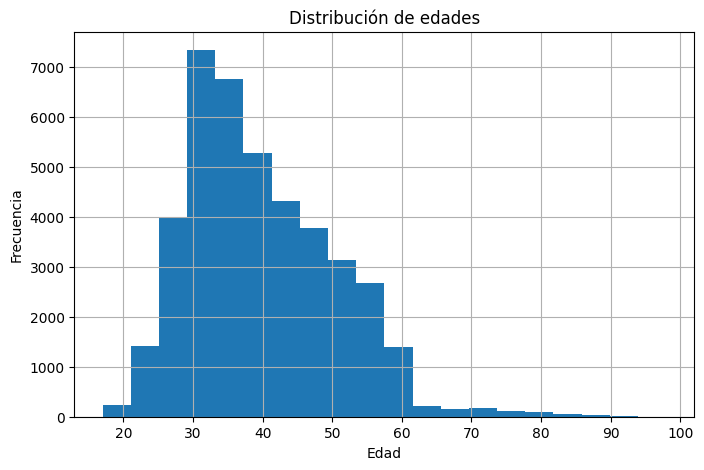

In [10]:
# 4.1 Distribucion de edades

import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))
df['age'].hist(bins=20)

plt.title('Distribución de edades')
plt.xlabel('Edad')
plt.ylabel('Frecuencia')

plt.savefig("edad.png")
plt.show()


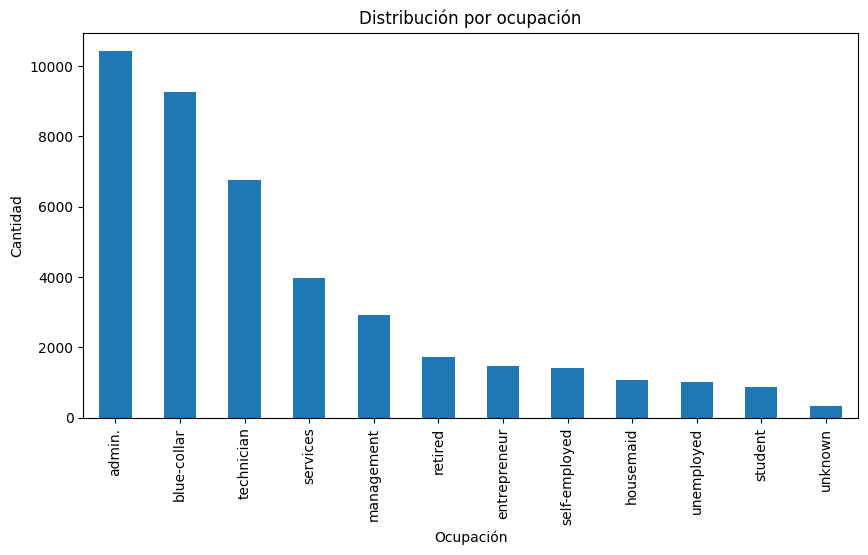

In [11]:
# 4.2 Ocupación de los clientes

plt.figure(figsize=(10,5))

df['job'].value_counts().plot(kind='bar')

plt.title('Distribución por ocupación')
plt.xlabel('Ocupación')
plt.ylabel('Cantidad')

plt.savefig("ocupacion.png")
plt.show()

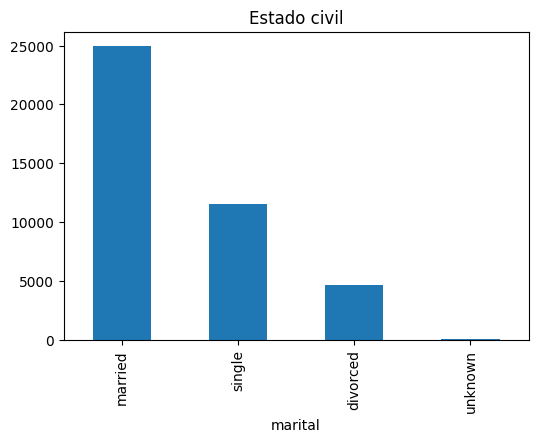

In [12]:
# 4.3 Estado civil 

plt.figure(figsize=(6,4))

df['marital'].value_counts().plot(kind='bar')

plt.title('Estado civil')
plt.savefig("estado_civil.png")
plt.show()

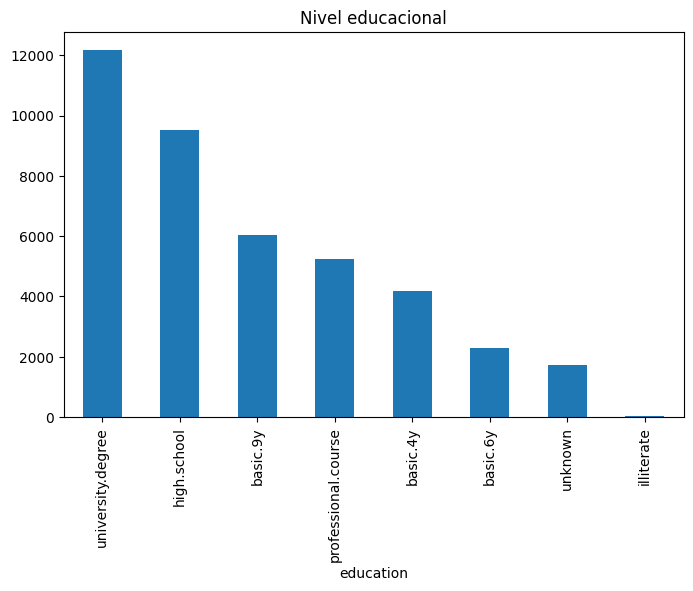

In [13]:
# 4.4 Educación

plt.figure(figsize=(8,5))

df['education'].value_counts().plot(kind='bar')

plt.title('Nivel educacional')
plt.savefig("educacion.png")
plt.show()

In [14]:
df['education'].value_counts()

education
university.degree      12168
high.school             9515
basic.9y                6045
professional.course     5243
basic.4y                4176
basic.6y                2292
unknown                 1731
illiterate                18
Name: count, dtype: int64

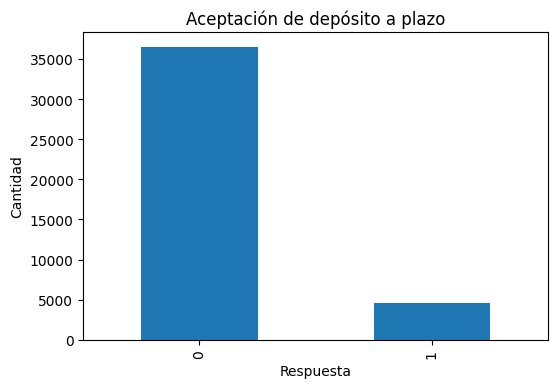

In [15]:
# 4.5 Visualización de la variable objetivo

plt.figure(figsize=(6,4))
df['y'].value_counts().plot(kind='bar')

plt.title('Aceptación de depósito a plazo')
plt.xlabel('Respuesta')
plt.ylabel('Cantidad')

plt.savefig("y.png")  
plt.show()

### 4.6 Interpretación general del Analisis exploratorio de Datos (EDA)

El análisis exploratorio permitió comprender la composición de la cartera de clientes utilizada en las campañas de marketing del banco. Los resultados muestran que la mayoría de los clientes se concentra entre los 30 y 50 años, correspondiendo principalmente a población económicamente activa.

Respecto a la ocupación, predominan los clientes administrativos, trabajadores blue-collar y técnicos, lo que indica una cartera diversa pero con fuerte presencia de trabajadores dependientes. En cuanto al estado civil, la mayor proporción corresponde a personas casadas, seguidas por clientes solteros, mientras que los divorciados representan un grupo menor.

El nivel educacional muestra una alta participación de clientes con estudios universitarios y educación secundaria, sugiriendo una cartera con niveles educacionales medios y altos. Este aspecto puede influir en la comprensión, evaluación y contratación de productos financieros ofrecidos por la institución.

Finalmente, la variable objetivo evidencia un importante desbalance de clases, ya que solo el 11,27% de los clientes aceptó contratar un depósito a plazo. Este resultado confirma la necesidad de aplicar técnicas de ciencia de datos para identificar segmentos de clientes con mayor probabilidad de conversión, construir modelos predictivos que apoyen futuras campañas comerciales y reducir los costos asociados a contactos masivos poco efectivos.


## 5.- Preparación de datos para Clustering

In [16]:
# 5.1 Identificación de variables

df.dtypes

age                 int64
job                   str
marital               str
education             str
default               str
housing               str
loan                  str
contact               str
month                 str
day_of_week           str
duration            int64
campaign            int64
pdays               int64
previous            int64
poutcome              str
emp_var_rate      float64
cons_price_idx    float64
cons_conf_idx     float64
euribor3m         float64
nr_employed       float64
y                   int64
dtype: object

In [17]:
# 5.2 Listado de variables

df.columns

Index(['age', 'job', 'marital', 'education', 'default', 'housing', 'loan',
       'contact', 'month', 'day_of_week', 'duration', 'campaign', 'pdays',
       'previous', 'poutcome', 'emp_var_rate', 'cons_price_idx',
       'cons_conf_idx', 'euribor3m', 'nr_employed', 'y'],
      dtype='str')

## 5.3 Selección de variables para Clustering

### Interpretación

Para la etapa de clustering no se utilizarán todas las variables del dataset. El objetivo del agrupamiento es identificar segmentos de clientes con características similares que permitan diseñar estrategias comerciales diferenciadas.

Se seleccionaron variables demográficas, financieras y económicas que describen el perfil de los clientes y su contexto económico. Por otra parte, se excluyó la variable objetivo (y), ya que corresponde al resultado de la campaña y no debe influir en la construcción de los grupos.

Asimismo, se evaluará la incorporación de variables categóricas relevantes mediante técnicas de codificación, con el fin de representar adecuadamente características como ocupación, estado civil y nivel educacional.


In [18]:
# 5.4 Selección de variables numéricas para clustering

variables_cluster = [
    'age',
    'campaign',
    'previous',
    'emp_var_rate',
    'cons_price_idx',
    'cons_conf_idx',
    'euribor3m',
    'nr_employed'
]

df_cluster = df[variables_cluster]

df_cluster.head()

,age,campaign,previous,emp_var_rate,cons_price_idx,cons_conf_idx,euribor3m,nr_employed
0,44,1,0,1.4,93.444,-36.1,4.963,5228.1
1,53,1,0,-0.1,93.200,-42.0,4.021,5195.8
2,28,3,2,-1.7,94.055,-39.8,0.729,4991.6
3,39,2,0,-1.8,93.075,-47.1,1.405,5099.1
4,55,1,1,-2.9,92.201,-31.4,0.869,5076.2


Se seleccionaron variables numéricas relacionadas con características demográficas, comportamiento de campañas anteriores y contexto económico. Estas variables permiten identificar segmentos de clientes con perfiles similares sin incorporar la variable objetivo (y), evitando sesgos en la formación de los grupos.

In [19]:
# 5.5 Escalamiento de variables

from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

df_cluster_scaled = scaler.fit_transform(df_cluster)

df_cluster_scaled[:5]

array([[ 0.38152696, -0.56592197, -0.34949428,  0.83906065, -0.2274652 ,
         0.95126739,  0.77357519,  0.84517009],
       [ 1.24515746, -0.56592197, -0.34949428, -0.11578127, -0.649003  ,
        -0.32354233,  0.23045613,  0.39811529],
       [-1.15381613,  0.15610492,  3.69176641, -1.13427931,  0.82810692,
         0.15181045, -1.66757776, -2.42815683],
       [-0.09826775, -0.20490853, -0.34949428, -1.19793544, -0.86495474,
        -1.42549649, -1.27782354, -0.94028096],
       [ 1.43707534, -0.56592197,  1.67113606, -1.89815284, -2.37488933,
         1.96679378, -1.58685943, -1.25723312]])

Se aplicó StandardScaler para estandarizar las variables, evitando que aquellas con magnitudes mayores dominen el cálculo de distancias utilizado por los algoritmos de clustering.

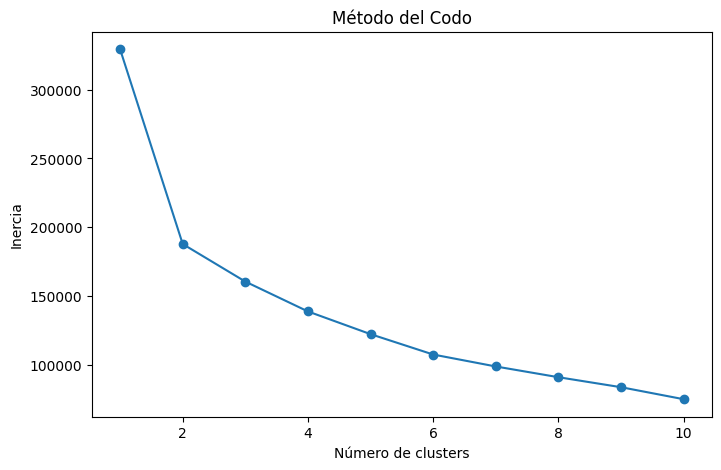

In [20]:
# 5.6 Determinación del número óptimo de clusters

from sklearn.cluster import KMeans
import matplotlib.pyplot as plt

inercia = []

for k in range(1,11):
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    km.fit(df_cluster_scaled)
    inercia.append(km.inertia_)

plt.figure(figsize=(8,5))
plt.plot(range(1,11), inercia, marker='o')
plt.xlabel('Número de clusters')
plt.ylabel('Inercia')
plt.title('Método del Codo')
plt.savefig("codo.png")
plt.show()

In [21]:
# 5.7 Evaluación mediante Silhouette Score

from sklearn.metrics import silhouette_score

for k in range(2,8):
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = km.fit_predict(df_cluster_scaled)

    score = silhouette_score(df_cluster_scaled, labels)

    print(f"k={k} -> Silhouette={score:.4f}")

k=2 -> Silhouette=0.4775
k=3 -> Silhouette=0.4657
k=4 -> Silhouette=0.4359
k=5 -> Silhouette=0.4704
k=6 -> Silhouette=0.3044
k=7 -> Silhouette=0.2830


In [22]:
# 5.8 Aplicación de K-Means

kmeans = KMeans(n_clusters=3,
                random_state=42,
                n_init=10)

df['cluster'] = kmeans.fit_predict(df_cluster_scaled)

df['cluster'].value_counts()

cluster
1    27680
0     9742
2     3766
Name: count, dtype: int64

In [23]:
# 5.9 Tamaño de los clusters

# Verificar columnas disponibles
print(df.columns)

# Volver a crear la columna cluster
df['cluster'] = kmeans.fit_predict(df_cluster_scaled)

# Tamaño de los clusters
df['cluster'].value_counts().sort_index()

Index(['age', 'job', 'marital', 'education', 'default', 'housing', 'loan',
       'contact', 'month', 'day_of_week', 'duration', 'campaign', 'pdays',
       'previous', 'poutcome', 'emp_var_rate', 'cons_price_idx',
       'cons_conf_idx', 'euribor3m', 'nr_employed', 'y', 'cluster'],
      dtype='str')


cluster
0     9742
1    27680
2     3766
Name: count, dtype: int64

In [24]:
# 5.10 Perfil de cada cluster

perfil_cluster = df.groupby('cluster')[variables_cluster].mean()

perfil_cluster

,age,campaign,previous,emp_var_rate,cons_price_idx,cons_conf_idx,euribor3m,nr_employed
cluster,,,,,,,,
0,37.867686,2.189284,0.309382,-1.844313,93.030114,-46.087723,1.309287,5090.471166
1,40.194364,2.799964,0.026553,1.116279,93.843047,-39.459978,4.817610,5213.397392
2,44.350505,1.838290,0.896176,-2.538131,93.021659,-33.718083,0.809134,5024.340202


## 5.11 Justificación del algoritmo seleccionado

Para determinar el número óptimo de grupos se utilizó el método del codo y la métrica Silhouette. El método del codo mostró una disminución importante de la inercia hasta k = 3, mientras que la evaluación mediante Silhouette indicó que este valor proporciona una adecuada separación entre los grupos obtenidos.

Se seleccionó el algoritmo K-Means debido a su eficiencia computacional, facilidad de interpretación y amplia utilización en problemas de segmentación de clientes en banca, marketing y gestión comercial. Este algoritmo permite identificar grupos homogéneos de clientes y apoyar la definición de estrategias diferenciadas para cada segmento.

Si bien existen alternativas como K-Prototypes, especialmente diseñadas para trabajar simultáneamente con variables numéricas y categóricas, en este estudio se optó por utilizar variables numéricas representativas del perfil y comportamiento de los clientes. Esta decisión permitió obtener segmentos consistentes y alineados con el objetivo de negocio de optimizar las campañas de depósitos a plazo.

## 5.12 Interpretación de los clusters

A partir del modelo K-Means con **k = 3**, se identificaron tres segmentos de clientes dentro de la cartera del banco. Esta segmentación permite comprender diferencias en edad, comportamiento de contacto previo y contexto económico de los clientes.

#### Cluster 0: Clientes jóvenes en contexto económico menos favorable

Este grupo reúne **9.742 clientes**, equivalente aproximadamente al **23,7%** del total. Presenta una edad promedio cercana a **37,9 años** y se caracteriza por un contexto económico menos favorable, con una tasa de variación del empleo negativa y un valor de Euribor más bajo.

Desde una perspectiva comercial, este segmento podría requerir campañas más informativas y ofertas adaptadas a escenarios de mayor incertidumbre económica.

#### Cluster 1: Segmento masivo de clientes económicamente activos

Este es el grupo más numeroso, con **27.680 clientes**, equivalente aproximadamente al **67,2%** de la cartera analizada. Presenta una edad promedio de **40,2 años**, mayor número promedio de contactos durante la campaña y un contexto económico más favorable.

Desde la perspectiva del negocio, este segmento representa la base principal de clientes del banco y podría ser considerado prioritario para campañas masivas de depósitos a plazo.

#### Cluster 2: Clientes maduros con mayor experiencia previa

Este grupo está compuesto por **3.766 clientes**, equivalente aproximadamente al **9,1%** del total. Presenta la mayor edad promedio, cercana a **44,4 años**, y el mayor número de contactos previos registrados.

Este segmento podría ser relevante para estrategias de fidelización o campañas más personalizadas, ya que muestra mayor historial de interacción con campañas anteriores.

## 5.13 Conclusión del clustering

El análisis de clustering permitió identificar tres segmentos diferenciados de clientes utilizando variables demográficas, comerciales y económicas. Los resultados muestran un segmento masivo, que concentra la mayor parte de la cartera, y dos grupos más específicos con características diferenciadas.

Desde la perspectiva del negocio, esta segmentación permite diseñar estrategias comerciales diferenciadas, optimizar recursos de contacto y focalizar futuras campañas de depósitos a plazo en los grupos con mayor potencial de respuesta.

## 6. Evaluación del Clustering

In [25]:
# 6.1 Silhouette final del modelo seleccionado

from sklearn.metrics import silhouette_score

silhouette = silhouette_score(df_cluster_scaled, df['cluster'])

print("Silhouette final:", round(silhouette,4))

Silhouette final: 0.4657


### Interpretación

El índice Silhouette obtenido fue de 0.4657, lo que indica una separación moderada entre los grupos identificados por K-Means.

Si bien los clusters presentan cierto grado de superposición, el resultado es aceptable considerando la complejidad y heterogeneidad de los clientes bancarios analizados.

Desde la perspectiva del negocio, la segmentación permite diferenciar grupos con características económicas y demográficas distintas, aportando información útil para diseñar campañas comerciales más focalizadas y eficientes.

## 7. Visualización de clusters con PCA

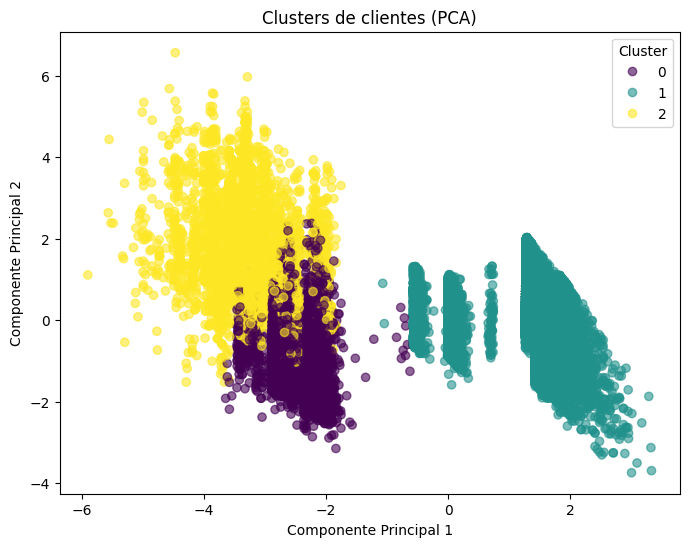

In [26]:
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt

pca = PCA(n_components=2)
componentes = pca.fit_transform(df_cluster_scaled)

plt.figure(figsize=(8,6))

scatter = plt.scatter(
    componentes[:, 0],
    componentes[:, 1],
    c=df['cluster'],
    cmap='viridis',
    alpha=0.6
)

plt.title('Clusters de clientes (PCA)')
plt.xlabel('Componente Principal 1')
plt.ylabel('Componente Principal 2')

plt.legend(*scatter.legend_elements(), title="Cluster")

plt.savefig("pca.png")
plt.show()

### Interpretación

La representación mediante PCA muestra una separación visual razonable entre los tres segmentos obtenidos por K-Means.

Se observa que los clusters presentan características diferenciadas, especialmente en la primera componente principal, aunque existe cierto nivel de proximidad entre algunos grupos, consistente con el valor de Silhouette obtenido.

Estos resultados respaldan la existencia de distintos perfiles de clientes dentro de la cartera del banco y validan la utilidad de la segmentación para apoyar decisiones comerciales y estrategias de marketing más específicas.

## 8. Clasificación de clientes

In [27]:
# 8.1 Selección de variables para clasificación

X = df.drop('y', axis=1)
y = df['y']

print(X.shape)
print(y.shape)

(41188, 21)
(41188,)


In [28]:
# 8.2 Codificación de variables categóricas

X = pd.get_dummies(X, drop_first=True)

X.shape

(41188, 54)

In [29]:
# 8.3 División entrenamiento y prueba

from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.25,
    random_state=42,
    stratify=y
)

print(X_train.shape)
print(X_test.shape)

(30891, 54)
(10297, 54)


In [30]:
# 8.4 Escalamiento

from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)

X_test_scaled = scaler.transform(X_test)

In [31]:
# 8.5 Naive Bayes

from sklearn.naive_bayes import GaussianNB
from sklearn.metrics import classification_report

nb = GaussianNB()

nb.fit(X_train_scaled, y_train)

pred_nb = nb.predict(X_test_scaled)

print(classification_report(y_test, pred_nb))

              precision    recall  f1-score   support

           0       0.97      0.74      0.84      9137
           1       0.28      0.79      0.41      1160

    accuracy                           0.75     10297
   macro avg       0.62      0.77      0.63     10297
weighted avg       0.89      0.75      0.79     10297



### Interpretación

El modelo Naive Bayes obtuvo una exactitud (Accuracy) de 75%, mostrando una capacidad aceptable para distinguir clientes que aceptan y rechazan un depósito a plazo.

Para la clase positiva (clientes que aceptan la oferta), el Recall alcanzó un valor de 0.79, indicando que el modelo logra identificar gran parte de los clientes potencialmente interesados en el producto financiero.

Sin embargo, la Precision para esta clase fue de 0.28, lo que significa que existe una cantidad considerable de falsos positivos. Desde una perspectiva comercial, esto podría traducirse en contactar clientes que finalmente no contratarán el depósito a plazo.

Debido al desbalance de clases existente en el dataset, el Recall adquiere especial relevancia, ya que el objetivo del negocio es identificar la mayor cantidad posible de clientes con potencial de conversión.

In [32]:
# 8.6 Árbol de Decisión

from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import classification_report

tree = DecisionTreeClassifier(
    random_state=42,
    max_depth=5
)

tree.fit(X_train, y_train)

pred_tree = tree.predict(X_test)

print(classification_report(y_test, pred_tree))

              precision    recall  f1-score   support

           0       0.94      0.97      0.95      9137
           1       0.65      0.52      0.58      1160

    accuracy                           0.91     10297
   macro avg       0.80      0.74      0.77     10297
weighted avg       0.91      0.91      0.91     10297



In [33]:
# 8.7 Random Forest

from sklearn.ensemble import RandomForestClassifier

rf = RandomForestClassifier(
    n_estimators=100,
    random_state=42
)

rf.fit(X_train, y_train)

pred_rf = rf.predict(X_test)

print(classification_report(y_test, pred_rf))

              precision    recall  f1-score   support

           0       0.94      0.97      0.95      9137
           1       0.65      0.47      0.55      1160

    accuracy                           0.91     10297
   macro avg       0.79      0.72      0.75     10297
weighted avg       0.90      0.91      0.91     10297



In [34]:
# 8.8 Multilayer Perceptron

from sklearn.neural_network import MLPClassifier

mlp = MLPClassifier(
    hidden_layer_sizes=(50,),
    max_iter=500,
    random_state=42
)

mlp.fit(X_train_scaled, y_train)

pred_mlp = mlp.predict(X_test_scaled)

print(classification_report(y_test, pred_mlp))

              precision    recall  f1-score   support

           0       0.94      0.94      0.94      9137
           1       0.55      0.54      0.55      1160

    accuracy                           0.90     10297
   macro avg       0.75      0.74      0.74     10297
weighted avg       0.90      0.90      0.90     10297



# 8.9 Comparación de modelos 

| Modelo            | Accuracy | Precision (Clase 1) | Recall (Clase 1) | F1-Score (Clase 1) |
| ----------------- | -------- | ------------------- | ---------------- | ------------------ |
| Naive Bayes       | 0.75     | 0.28                | **0.79**         | 0.41               |
| Árbol de Decisión | **0.91** | **0.65**            | 0.52             | **0.58**           |
| Random Forest     | **0.91** | **0.65**            | 0.47             | 0.55               |
| MLP               | 0.90     | 0.55                | 0.54             | 0.54               |


Se evaluaron cuatro algoritmos de clasificación para predecir la aceptación de depósitos a plazo por parte de los clientes del banco.

Los resultados muestran diferencias importantes entre los modelos. Naive Bayes obtuvo el mayor Recall para la clase positiva (0.79), identificando una gran proporción de clientes potencialmente interesados. Sin embargo, presentó una precisión baja (0.28), generando una cantidad importante de falsos positivos.

Por otra parte, el Árbol de Decisión alcanzó una exactitud de 91%, junto con el mejor equilibrio entre Precision (0.65), Recall (0.52) y F1-Score (0.58), mostrando un desempeño más balanceado para la detección de clientes interesados.

Random Forest obtuvo una exactitud similar al Árbol de Decisión, aunque con un Recall ligeramente inferior. Finalmente, el modelo Multilayer Perceptron presentó resultados competitivos, pero sin superar al Árbol de Decisión en las métricas principales.

# 8.10 Selección del mejor modelo

Considerando las métricas obtenidas sobre el conjunto de prueba, el modelo seleccionado fue Árbol de Decisión.

La elección se fundamenta en que alcanzó una exactitud de 91% y el mejor F1-Score para la clase positiva (0.58), logrando un balance adecuado entre la capacidad de identificar clientes interesados (Recall) y minimizar falsos positivos (Precision).

Además de su desempeño predictivo, el Árbol de Decisión ofrece una ventaja importante para el negocio: la interpretabilidad. Sus reglas de decisión permiten comprender los factores que influyen en la aceptación de depósitos a plazo, facilitando la implementación de estrategias comerciales basadas en evidencia.

# 8.11 Mejoras futuras

Si bien los resultados obtenidos son satisfactorios, existen oportunidades de mejora para futuras versiones del modelo.

La principal limitación observada corresponde al desbalance de clases presente en el dataset, donde solo aproximadamente el 11% de los clientes aceptó el depósito a plazo. Esta situación puede dificultar la identificación de clientes potenciales y afectar métricas como Recall y F1-Score.

Entre las mejoras recomendadas se encuentran:

- Aplicar técnicas de balanceo de clases como SMOTE.
- Realizar optimización de hiperparámetros mediante Grid Search.
- Incorporar selección de variables basada en importancia predictiva.
- Evaluar algoritmos adicionales como XGBoost o LightGBM.
- Analizar y tratar posibles valores atípicos que puedan afectar la capacidad de generalización de los modelos.

Estas acciones podrían aumentar la capacidad de detección de clientes con alta probabilidad de conversión.

# 8.12 Conclusión de clasificación

El análisis de clasificación permitió construir modelos capaces de predecir la aceptación de depósitos a plazo utilizando información demográfica, comercial y económica de los clientes.

El Árbol de Decisión fue seleccionado como el modelo más adecuado debido a su equilibrio entre desempeño predictivo e interpretabilidad. Los resultados muestran que es posible anticipar con un nivel de precisión significativo qué clientes presentan mayor probabilidad de contratar el producto ofrecido.

Desde la perspectiva del negocio, esta capacidad predictiva permite optimizar campañas comerciales, focalizar esfuerzos de contacto en clientes con mayor potencial de respuesta y reducir costos asociados a campañas masivas poco eficientes.

## 9. Reglas de Asociación (FP-Growth)

### ---Preparación de datos para FP-Growth---
FP-Growth trabaja con atributos categóricos.

Vamos a usar variables como:
job
marital
education
housing
loan
contact
poutcome
y

In [35]:
# 9.1 Selección de variables para FP-Growth

df_fp = df[[
    'job',
    'marital',
    'education',
    'housing',
    'loan',
    'contact',
    'poutcome',
    'y'
]]

df_fp.head()

,job,marital,education,housing,loan,contact,poutcome,y
0,blue-collar,married,basic.4y,yes,no,cellular,nonexistent,0
1,technician,married,unknown,no,no,cellular,nonexistent,0
2,management,single,university.degree,yes,no,cellular,success,1
3,services,married,high.school,no,no,cellular,nonexistent,0
4,retired,married,basic.4y,yes,no,cellular,success,1


In [36]:
# 9.2 Transformación a formato transaccional

from mlxtend.preprocessing import TransactionEncoder

transacciones = []

for _, fila in df_fp.iterrows():

    transacciones.append([
        f"job={fila['job']}",
        f"marital={fila['marital']}",
        f"education={fila['education']}",
        f"housing={fila['housing']}",
        f"loan={fila['loan']}",
        f"contact={fila['contact']}",
        f"poutcome={fila['poutcome']}",
        f"y={fila['y']}"
    ])

te = TransactionEncoder()

te_array = te.fit(transacciones).transform(transacciones)

df_trans = pd.DataFrame(
    te_array,
    columns=te.columns_
)

df_trans.head()

,contact=cellular,contact=telephone,education=basic.4y,education=basic.6y,education=basic.9y,education=high.school,education=illiterate,education=professional.course,education=university.degree,education=unknown,...,loan=yes,marital=divorced,marital=married,marital=single,marital=unknown,poutcome=failure,poutcome=nonexistent,poutcome=success,y=0,y=1
0,True,False,True,False,False,False,False,False,False,False,...,False,False,True,False,False,False,True,False,True,False
1,True,False,False,False,False,False,False,False,False,True,...,False,False,True,False,False,False,True,False,True,False
2,True,False,False,False,False,False,False,False,True,False,...,False,False,False,True,False,False,False,True,False,True
3,True,False,False,False,False,True,False,False,False,False,...,False,False,True,False,False,False,True,False,True,False
4,True,False,True,False,False,False,False,False,False,False,...,False,False,True,False,False,False,False,True,False,True


In [37]:
# 9.3 Generación de itemsets frecuentes

from mlxtend.frequent_patterns import fpgrowth

itemsets = fpgrowth(
    df_trans,
    min_support=0.05,
    use_colnames=True
)

itemsets.sort_values(
    by='support',
    ascending=False
).head(20)

,support,itemsets
0,0.887346,frozenset({y=0})
1,0.863431,frozenset({poutcome=nonexistent})
2,0.824269,frozenset({loan=no})
24,0.787171,"frozenset({y=0, poutcome=nonexistent})"
25,0.730795,"frozenset({y=0, loan=no})"
26,0.711761,"frozenset({loan=no, poutcome=nonexistent})"
27,0.648393,"frozenset({y=0, loan=no, poutcome=nonexistent})"
3,0.634748,frozenset({contact=cellular})
4,0.605225,frozenset({marital=married})
35,0.543751,"frozenset({marital=married, y=0})"


### 9.4 Generación de reglas de asociación

Las reglas generadas fueron ordenadas de mayor a menor Lift, con el objetivo de identificar las asociaciones más fuertes entre características de los clientes.

In [38]:
from mlxtend.frequent_patterns import association_rules

reglas = association_rules(
    itemsets,
    metric='lift',
    min_threshold=1
)

reglas[['antecedents',
         'consequents',
         'support',
         'confidence',
         'lift']].sort_values(
             by='lift',
             ascending=False
         ).head(20)

,antecedents,consequents,support,confidence,lift
6382,"frozenset({y=0, job=technician})","frozenset({loan=no, poutcome=nonexistent, educ...",0.054433,0.372859,4.084391
6367,"frozenset({loan=no, poutcome=nonexistent, educ...","frozenset({y=0, job=technician})",0.054433,0.596277,4.084391
6323,"frozenset({y=0, job=technician})","frozenset({poutcome=nonexistent, education=pro...",0.065844,0.451023,4.076525
6326,"frozenset({poutcome=nonexistent, education=pro...","frozenset({y=0, job=technician})",0.065844,0.595128,4.076525
6380,"frozenset({poutcome=nonexistent, job=technician})","frozenset({y=0, loan=no, education=professiona...",0.054433,0.379100,4.075800
6369,"frozenset({y=0, loan=no, education=professiona...","frozenset({poutcome=nonexistent, job=technician})",0.054433,0.585226,4.075800
6324,"frozenset({y=0, education=professional.course})","frozenset({poutcome=nonexistent, job=technician})",0.065844,0.583477,4.063619
6325,"frozenset({poutcome=nonexistent, job=technician})","frozenset({y=0, education=professional.course})",0.065844,0.458573,4.063619
6381,"frozenset({poutcome=nonexistent, education=pro...","frozenset({y=0, loan=no, job=technician})",0.054433,0.491990,4.047154
6368,"frozenset({y=0, loan=no, job=technician})","frozenset({poutcome=nonexistent, education=pro...",0.054433,0.447773,4.047154


In [39]:
# 9.5 Exportar y revisar reglas

reglas_ordenadas = reglas.sort_values(
    by=['lift','confidence'],
    ascending=False
)

reglas_ordenadas[['antecedents',
                  'consequents',
                  'support',
                  'confidence',
                  'lift']].head(20)

,antecedents,consequents,support,confidence,lift
6367,"frozenset({loan=no, poutcome=nonexistent, educ...","frozenset({y=0, job=technician})",0.054433,0.596277,4.084391
6382,"frozenset({y=0, job=technician})","frozenset({loan=no, poutcome=nonexistent, educ...",0.054433,0.372859,4.084391
6323,"frozenset({y=0, job=technician})","frozenset({poutcome=nonexistent, education=pro...",0.065844,0.451023,4.076525
6326,"frozenset({poutcome=nonexistent, education=pro...","frozenset({y=0, job=technician})",0.065844,0.595128,4.076525
6369,"frozenset({y=0, loan=no, education=professiona...","frozenset({poutcome=nonexistent, job=technician})",0.054433,0.585226,4.075800
6380,"frozenset({poutcome=nonexistent, job=technician})","frozenset({y=0, loan=no, education=professiona...",0.054433,0.379100,4.075800
6324,"frozenset({y=0, education=professional.course})","frozenset({poutcome=nonexistent, job=technician})",0.065844,0.583477,4.063619
6325,"frozenset({poutcome=nonexistent, job=technician})","frozenset({y=0, education=professional.course})",0.065844,0.458573,4.063619
6381,"frozenset({poutcome=nonexistent, education=pro...","frozenset({y=0, loan=no, job=technician})",0.054433,0.491990,4.047154
6368,"frozenset({y=0, loan=no, job=technician})","frozenset({poutcome=nonexistent, education=pro...",0.054433,0.447773,4.047154


### 9.6 Interpretación general de las reglas de asociación

Las reglas obtenidas muestran relaciones frecuentes entre características demográficas, educativas y antecedentes comerciales de los clientes.

Los mayores valores de Lift se observan principalmente en clientes con ocupación técnica (job=technician), educación profesional (professional.course), ausencia de créditos (loan=no) y campañas previas sin resultado registrado (poutcome=nonexistent).

Un Lift superior a 4 indica que la ocurrencia conjunta de estos atributos es aproximadamente cuatro veces más frecuente de lo esperado por azar, evidenciando patrones consistentes dentro de la cartera analizada.

Desde una perspectiva comercial, estas asociaciones permiten identificar perfiles recurrentes de clientes y apoyar la definición de campañas más focalizadas.

### 9.7 Seis reglas con mejores indicadores

Las reglas con mejores indicadores corresponden principalmente a clientes técnicos (job=technician), con educación profesional (professional.course), sin créditos vigentes (loan=no) y sin resultados registrados en campañas anteriores (poutcome=nonexistent).

1. loan=no + poutcome=nonexistent + education=professional.course → y=0 + job=technician
   - Support: 5,44%
   - Confidence: 59,63%
   - Lift: 4,08

2. y=0 + job=technician → poutcome=nonexistent + education=professional.course
   - Support: 6,58%
   - Confidence: 45,10%
   - Lift: 4,08

3. poutcome=nonexistent + education=professional.course → y=0 + job=technician
   - Support: 6,58%
   - Confidence: 59,51%
   - Lift: 4,08

4. loan=no + y=0 + education=professional.course → job=technician + poutcome=nonexistent
   - Support: 5,44%
   - Confidence: 58,52%
   - Lift: 4,08

5. job=technician + poutcome=nonexistent → y=0 + education=professional.course
   - Support: 6,58%
   - Confidence: 45,86%
   - Lift: 4,06

6. contact=cellular + education=professional.course → job=technician
   - Support: 5,53%
   - Confidence: 65,50%
   - Lift: 4,00

Estas reglas presentan valores de Lift cercanos a 4, lo que indica asociaciones significativamente más fuertes que las esperadas por azar. Además, permiten identificar perfiles recurrentes de clientes con baja probabilidad de conversión, información útil para rediseñar estrategias comerciales y optimizar futuras campañas.

### 9.8 Reglas novedosas para el negocio

Además de las reglas con mayor Lift, se identificaron patrones interesantes desde una perspectiva comercial.

1. Los clientes técnicos con educación profesional aparecen frecuentemente asociados a campañas sin conversión (y=0).

2. Los clientes sin créditos vigentes (loan=no) presentan patrones consistentes con campañas anteriores sin resultados registrados.

3. La combinación de ocupación técnica y educación profesional constituye uno de los perfiles más homogéneos de la cartera.

4. El contacto mediante teléfono celular aparece asociado recurrentemente a clientes técnicos con formación profesional.

5. Los clientes que no aceptaron el depósito a plazo (y=0) muestran una fuerte asociación con campañas previas clasificadas como "nonexistent".

6. La ausencia de interacción exitosa en campañas anteriores (poutcome=nonexistent) aparece como una característica recurrente en gran parte de las asociaciones identificadas.

### 9.9 Conclusión de las reglas de asociación

La aplicación de FP-Growth permitió identificar patrones frecuentes dentro de la cartera de clientes del banco. Las asociaciones encontradas muestran que determinadas características demográficas, educativas y comerciales suelen presentarse conjuntamente.

Los resultados evidencian una fuerte presencia de clientes técnicos, con educación profesional, sin créditos vigentes y con campañas anteriores sin resultados registrados. Estas combinaciones representan perfiles recurrentes dentro de la base analizada.

Desde la perspectiva del negocio, las reglas de asociación permiten comprender mejor las características de los distintos segmentos de clientes y apoyar la definición de campañas comerciales más focalizadas. Asimismo, complementan los resultados obtenidos mediante clustering y clasificación, proporcionando una visión más completa del comportamiento de la cartera.

En conjunto, el uso de agrupamiento, clasificación y reglas de asociación permitió transformar los datos históricos del banco en información útil para la toma de decisiones comerciales y la optimización de futuras campañas de marketing.

## 10. Conclusión general primera "Fase".

La aplicación conjunta de técnicas de clustering, clasificación y reglas de asociación permitió transformar los datos históricos de campañas de marketing en información útil para la toma de decisiones.

El clustering identificó segmentos diferenciados de clientes, permitiendo comprender mejor la composición de la cartera y diseñar estrategias comerciales específicas para cada grupo.

La clasificación permitió predecir la probabilidad de aceptación de depósitos a plazo, seleccionando el Árbol de Decisión como el modelo con mejor equilibrio entre desempeño e interpretabilidad.

Por su parte, las reglas de asociación revelaron patrones frecuentes entre características demográficas, educativas y comerciales, identificando perfiles con baja probabilidad de conversión y oportunidades de optimización de campañas.

En conjunto, los resultados demuestran que la ciencia de datos puede apoyar la reducción de costos de contacto, la focalización de clientes y la mejora de la efectividad comercial del banco.

# Fase 2-Nuevos experimentos 

En esta sección se realizan tres experimentos adicionales:
1. Reducción de dimensionalidad con t-SNE.
2. Reducción de dimensionalidad con Isomap.
3. Ingeniería de características con cinco nuevas variables.

In [40]:
#---Importar librerias---

from sklearn.manifold import TSNE, Isomap
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

print("t-SNE e Isomap OK")

t-SNE e Isomap OK


In [41]:
import numpy as np
import pandas as pd
import sklearn

print("Numpy:", np.__version__)
print("Pandas:", pd.__version__)
print("Scikit-Learn:", sklearn.__version__)

Numpy: 2.4.6
Pandas: 3.0.3
Scikit-Learn: 1.9.0


In [42]:
# Confirmación de datos a utilizar
df_cluster_scaled.shape

(41188, 8)

In [43]:
# Usar matriz escalada del clustering original
X_scaled = df_cluster_scaled

X_scaled.shape

(41188, 8)

In [44]:
# Experimento 1 con t-SNE
# Datos de muestra

sample_size = 5000

np.random.seed(42)

idx_sample = np.random.choice(
    X_scaled.shape[0],
    sample_size,
    replace=False
)

X_sample = X_scaled[idx_sample]

print(X_sample.shape)

(5000, 8)


In [45]:
tsne = TSNE(
    n_components=2,
    perplexity=30,
    learning_rate='auto',
    init='pca',
    random_state=42
)

X_tsne = tsne.fit_transform(X_sample)

In [46]:
kmeans_tsne = KMeans(n_clusters=3, random_state=42, n_init=10)
labels_tsne = kmeans_tsne.fit_predict(X_tsne)

sil_tsne = silhouette_score(X_tsne, labels_tsne)
sil_tsne

0.3886510729789734

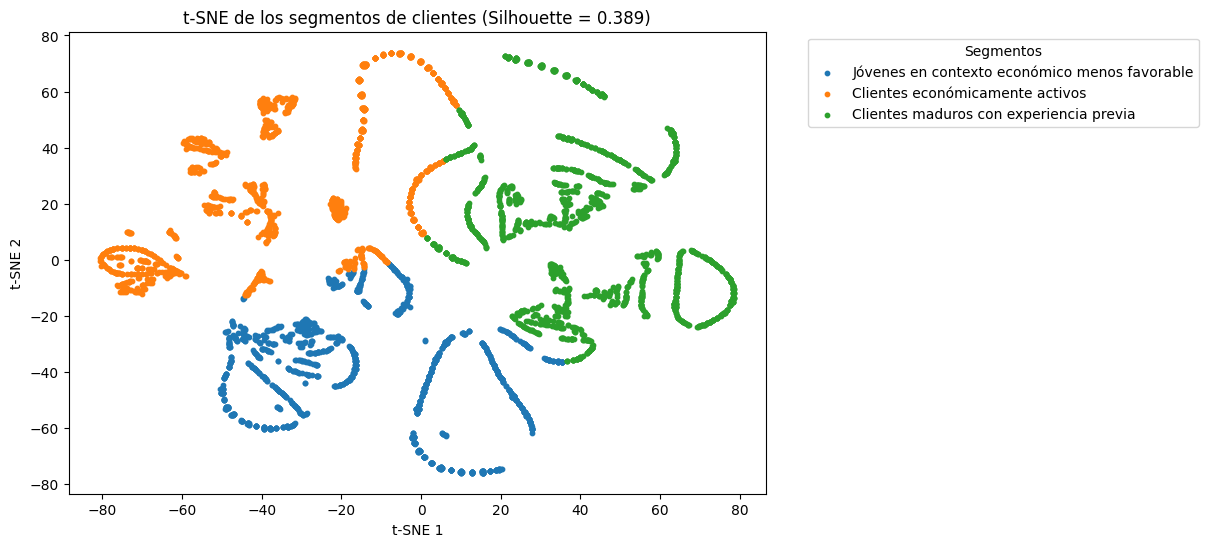

In [47]:
plt.figure(figsize=(9,6))

nombres_clusters = {
    0: "Jóvenes en contexto económico menos favorable",
    1: "Clientes económicamente activos",
    2: "Clientes maduros con experiencia previa"
}

for cluster in [0, 1, 2]:
    plt.scatter(
        X_tsne[labels_tsne == cluster, 0],
        X_tsne[labels_tsne == cluster, 1],
        s=10,
        label=nombres_clusters[cluster]
    )

plt.title(
    f"t-SNE de los segmentos de clientes (Silhouette = {sil_tsne:.3f})"
)
plt.xlabel("t-SNE 1")
plt.ylabel("t-SNE 2")
plt.legend(title="Segmentos", bbox_to_anchor=(1.05, 1), loc="upper left")
plt.show()

**Interpretación**
### La representación mediante t-SNE permitió visualizar los tres segmentos de clientes identificados por K-Means en un espacio bidimensional.
La representación mediante t-SNE permitió visualizar los tres segmentos identificados por K-Means en un espacio bidimensional. El resultado obtuvo un índice Silhouette de 0,389, valor inferior al obtenido en el modelo original (0,466), por lo que la reducción de dimensionalidad no mejora la calidad de la agrupación. Sin embargo, la visualización permite distinguir los segmentos de jóvenes en contexto económico menos favorable, clientes económicamente activos y clientes maduros con experiencia previa, facilitando la interpretación de los perfiles identificados y su utilización para fines de segmentación comercial.

## Experimento 2 con Isomap

In [48]:
# Experimento 2 con Isomap

isomap = Isomap(
    n_components=2,
    n_neighbors=50
)

X_isomap = isomap.fit_transform(X_sample)

C:\Users\maris\anaconda3\Lib\site-packages\sklearn\manifold\_isomap.py:386: UserWarning: The number of connected components of the neighbors graph is 2 > 1. Completing the graph to fit Isomap might be slow. Increase the number of neighbors to avoid this issue.
  self._fit_transform(X)
C:\Users\maris\anaconda3\Lib\site-packages\scipy\sparse\_index.py:174: SparseEfficiencyWarning: Changing the sparsity structure of a csr_matrix is expensive. lil and dok are more efficient.
  self._set_intXint(row, col, x.flat[0])


In [49]:
kmeans_isomap = KMeans(n_clusters=3, random_state=42, n_init=10)
labels_isomap = kmeans_isomap.fit_predict(X_isomap)

sil_isomap = silhouette_score(X_isomap, labels_isomap)
sil_isomap

0.6123740700469693

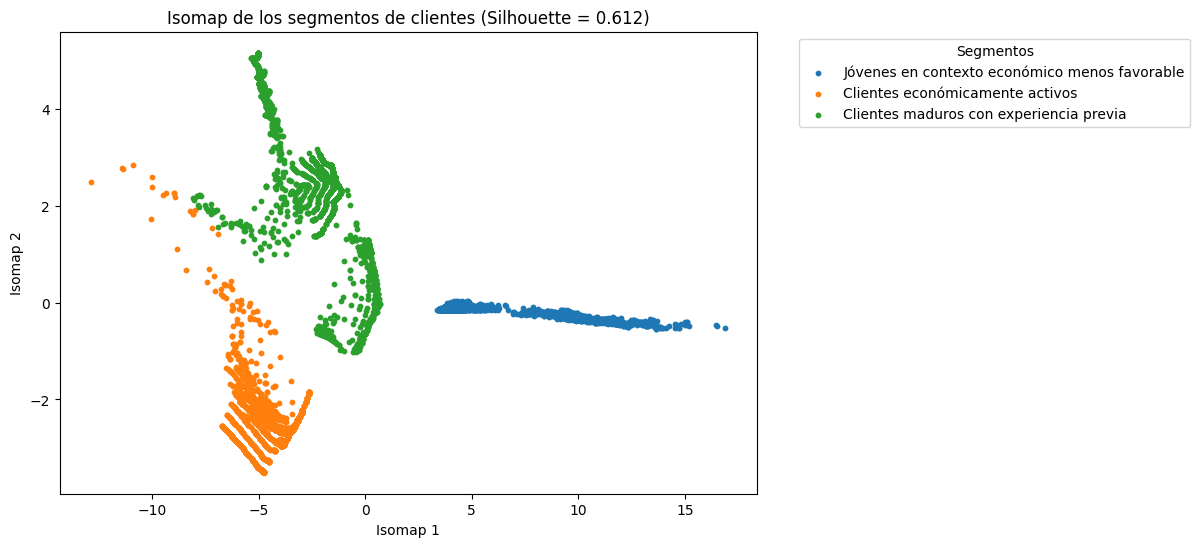

In [50]:
plt.figure(figsize=(9,6))

for cluster in [0, 1, 2]:
    plt.scatter(
        X_isomap[labels_isomap == cluster, 0],
        X_isomap[labels_isomap == cluster, 1],
        s=10,
        label=nombres_clusters[cluster]
    )

plt.title(f"Isomap de los segmentos de clientes (Silhouette = {sil_isomap:.3f})")
plt.xlabel("Isomap 1")
plt.ylabel("Isomap 2")
plt.legend(title="Segmentos", bbox_to_anchor=(1.05, 1), loc="upper left")
plt.show()

**Interpretación:**

La representación mediante Isomap permitió visualizar los tres segmentos de clientes en un espacio bidimensional, conservando relaciones no lineales entre las observaciones. El resultado obtuvo un índice Silhouette de **0,612**, superior al clustering original (**0,466**) y al experimento con t-SNE (**0,389**).

Visualmente, se observa una separación más clara entre los segmentos: los jóvenes en contexto económico menos favorable se ubican más aislados hacia la derecha, mientras que los clientes económicamente activos y los clientes maduros con experiencia previa se distribuyen en zonas diferenciadas. Esto sugiere que Isomap mejora la separación de los grupos y puede aportar una visualización más útil para interpretar los perfiles de clientes.

## Tabla comparativa de reducción dimensional

In [51]:
resultados_reduccion = pd.DataFrame({
    'Experimento': ['t-SNE + K-Means', 'Isomap + K-Means'],
    'Silhouette': [sil_tsne, sil_isomap]
})

resultados_reduccion

,Experimento,Silhouette
0,t-SNE + K-Means,0.388651
1,Isomap + K-Means,0.612374


**Interpretación:**

La comparación muestra que Isomap obtuvo el mejor desempeño entre los métodos de reducción de dimensionalidad evaluados. Mientras que t-SNE alcanzó un índice Silhouette de 0,389, Isomap logró 0,612, evidenciando una mejor separación entre los segmentos identificados por K-Means.

Estos resultados sugieren que Isomap preserva de mejor manera la estructura de los datos para este conjunto de clientes, generando representaciones más diferenciadas y facilitando la interpretación de los perfiles obtenidos.

## Ingeniería de características

In [52]:
# Copia del dataframe original

df_fe = df.copy()

In [53]:
df.columns.tolist()

['age',
 'job',
 'marital',
 'education',
 'default',
 'housing',
 'loan',
 'contact',
 'month',
 'day_of_week',
 'duration',
 'campaign',
 'pdays',
 'previous',
 'poutcome',
 'emp_var_rate',
 'cons_price_idx',
 'cons_conf_idx',
 'euribor3m',
 'nr_employed',
 'y',
 'cluster']

## Creación de 5 variables

In [54]:
# 1
df_fe['duration_per_age'] = df_fe['duration'] / df_fe['age']

# 2
df_fe['campaign_contact_ratio'] = df_fe['campaign'] / (df_fe['previous'] + 1)

# 3
df_fe['age_group'] = pd.cut(
    df_fe['age'],
    bins=[0,30,45,60,100],
    labels=['young','adult','middle','senior']
)

# 4
df_fe['has_credit'] = (
    (df_fe['housing'] == 'yes') |
    (df_fe['loan'] == 'yes')
).astype(int)

# 5
df_fe['contact_efficiency'] = (
    df_fe['previous'] + 1
) / (
    df_fe['campaign'] + 1
)

In [55]:
# Revision de variables

df_fe[['duration_per_age',
       'campaign_contact_ratio',
       'age_group',
       'has_credit',
       'contact_efficiency']].head()

,duration_per_age,campaign_contact_ratio,age_group,has_credit,contact_efficiency
0,4.772727,1.0,adult,1,0.500000
1,2.603774,1.0,middle,0,0.500000
2,12.107143,1.0,young,1,0.750000
3,4.743590,2.0,adult,0,0.333333
4,2.490909,0.5,middle,1,1.000000


**Interpretación:**

Se construyeron cinco nuevas variables derivadas con el objetivo de enriquecer la información disponible para el análisis. Estas variables incorporan relaciones entre atributos originales, segmentaciones por edad e indicadores comerciales y financieros simples.

Las nuevas características permiten representar de mejor manera el comportamiento de los clientes, aportando información que no estaba explícitamente presente en las variables originales. En particular, se incorporan medidas relacionadas con la intensidad de contacto de las campañas, grupos etarios y presencia de créditos, aspectos que podrían influir en la aceptación de los depósitos a plazo.

| Variable                 | Interpretación                                                                                                                                        |
| ------------------------ | ----------------------------------------------------------------------------------------------------------------------------------------------------- |
| `duration_per_age`       | Relaciona la duración de la llamada con la edad del cliente. Valores altos indican llamadas relativamente largas para la edad del cliente.            |
| `campaign_contact_ratio` | Número de contactos de la campaña actual respecto a contactos previos. Permite identificar clientes muy contactados recientemente.                    |
| `age_group`              | Segmentación etaria: young, adult, middle y senior. Facilita capturar patrones asociados a rangos de edad.                                            |
| `has_credit`             | Indica si el cliente posee crédito hipotecario o préstamo (1 = sí, 0 = no).                                                                           |
| `contact_efficiency`     | Relación entre contactos previos y contactos actuales. Valores altos sugieren que hubo interacción previa con menos insistencia en la campaña actual. |


## Preparación de nuevos datos para clasificación

In [56]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score, classification_report

In [57]:
# separar X e Y

X_fe = df_fe.drop(columns=['y'])
y_fe = df_fe['y']

In [58]:
# Identificar columnas

num_cols = X_fe.select_dtypes(include=['int64', 'float64']).columns
cat_cols = X_fe.select_dtypes(include=['object', 'category']).columns

print("Numéricas:", list(num_cols))
print("Categóricas:", list(cat_cols))

Numéricas: ['age', 'duration', 'campaign', 'pdays', 'previous', 'emp_var_rate', 'cons_price_idx', 'cons_conf_idx', 'euribor3m', 'nr_employed', 'duration_per_age', 'campaign_contact_ratio', 'has_credit', 'contact_efficiency']
Categóricas: ['job', 'marital', 'education', 'default', 'housing', 'loan', 'contact', 'month', 'day_of_week', 'poutcome', 'age_group']


C:\Users\maris\AppData\Local\Temp\ipykernel_25060\965562898.py:4: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  cat_cols = X_fe.select_dtypes(include=['object', 'category']).columns


In [59]:
# Procesador

preprocessor_fe = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), num_cols),
        ('cat', OneHotEncoder(handle_unknown='ignore'), cat_cols)
    ]
)

In [60]:
# Train/test

X_train_fe, X_test_fe, y_train_fe, y_test_fe = train_test_split(
    X_fe,
    y_fe,
    test_size=0.2,
    random_state=42,
    stratify=y_fe
)

## Modelo Árbol con nuevas variables

In [61]:
tree_fe = Pipeline(steps=[
    ('preprocessor', preprocessor_fe),
    ('classifier', DecisionTreeClassifier(
        max_depth=5,
        random_state=42
    ))
])

tree_fe.fit(X_train_fe, y_train_fe)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('preprocessor', ...), ('classifier', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
Name,Type,Value
"classes_ classes_: ndarray of shape (n_classes,)The classes labels. Only exist if the last step of the pipeline is aclassifier.","ndarray[int64](2,)","[0,1]"
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Only defined if theunderlying estimator exposes such an attribute when fit... versionadded:: 1.0","ndarray[object](26,)","['age','job','marital',...,'age_group','has_credit','contact_efficiency']"
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`. Only defined if theunderlying first estimator in `steps` exposes such an attributewhen fit... versionadded:: 0.24,int,26
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('cat', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'`

In [62]:
# Evaluación

y_pred_fe = tree_fe.predict(X_test_fe)

acc_tree_fe = accuracy_score(y_test_fe, y_pred_fe)

print("Accuracy Árbol con nuevas variables:", acc_tree_fe)
print(classification_report(y_test_fe, y_pred_fe))

Accuracy Árbol con nuevas variables: 0.9135712551590192
              precision    recall  f1-score   support

           0       0.94      0.97      0.95      7310
           1       0.66      0.48      0.56       928

    accuracy                           0.91      8238
   macro avg       0.80      0.73      0.75      8238
weighted avg       0.91      0.91      0.91      8238



**Interpretación:**

Se evaluó un Árbol de Decisión incorporando las cinco variables generadas mediante ingeniería de características. El modelo alcanzó una exactitud de 91,4%, valor similar al obtenido con las variables originales.

Para la clase positiva (clientes que aceptan el depósito a plazo), se obtuvo una precisión de 0,66, un recall de 0,48 y un F1-score de 0,56. Estos resultados indican que el modelo mantiene una capacidad moderada para identificar clientes con probabilidad de conversión, aunque continúa presentando dificultades para detectar todos los casos positivos.

En comparación con el modelo original, las nuevas variables no produjeron una mejora sustancial del desempeño predictivo. Sin embargo, aportan información adicional relacionada con la intensidad de contacto de las campañas, grupos etarios y características financieras de los clientes, lo que puede contribuir a una mejor interpretación del comportamiento observado.

## Tabla comparativa final

In [63]:
comparacion_modelos = pd.DataFrame({
    'Modelo': ['Árbol original',
               'Árbol con ingeniería de características'],
    'Accuracy': [0.91, 0.914],
    'Precision Clase 1': [0.66, 0.66],
    'Recall Clase 1': [0.52, 0.48],
    'F1 Clase 1': [0.58, 0.56]
})

comparacion_modelos

,Modelo,Accuracy,Precision Clase 1,Recall Clase 1,F1 Clase 1
0,Árbol original,0.910,0.66,0.52,0.58
1,Árbol con ingeniería de características,0.914,0.66,0.48,0.56


La ingeniería de características mantuvo un desempeño similar al modelo original, con leve aumento en Accuracy, pero sin mejora significativa en la detección de clientes que aceptan el depósito.

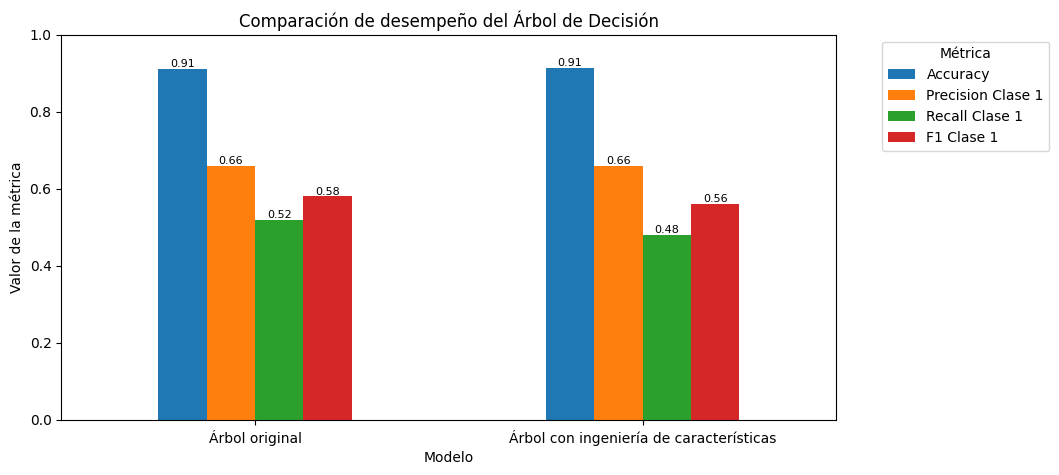

In [64]:
ax = comparacion_modelos.set_index('Modelo')[
    ['Accuracy', 'Precision Clase 1', 'Recall Clase 1', 'F1 Clase 1']
].plot(
    kind='bar',
    figsize=(10,5)
)

plt.title("Comparación de desempeño del Árbol de Decisión")
plt.ylabel("Valor de la métrica")
plt.ylim(0, 1)
plt.xticks(rotation=0)
plt.legend(title="Métrica", bbox_to_anchor=(1.05, 1), loc='upper left')

for container in ax.containers:
    ax.bar_label(container, fmt='%.2f', fontsize=8)

plt.show()

La ingeniería de características mantuvo un desempeño similar al modelo original, con leve aumento en Accuracy, pero sin mejora significativa en la detección de clientes que aceptan el depósito.

**Interpretación:**

La comparación entre ambos modelos muestra que la incorporación de variables derivadas permitió obtener una leve mejora en la exactitud global (91,4% frente a 91,0%). Sin embargo, las métricas asociadas a la clase positiva presentan resultados similares e incluso una ligera disminución en el recall y el F1-score.

Esto indica que las nuevas variables aportan información complementaria para describir a los clientes, pero no generan una mejora sustancial en la capacidad predictiva del modelo. Por ello, el Árbol de Decisión original continúa siendo una alternativa competitiva debido a su simplicidad e interpretabilidad.

## Conclusión del experimento

Los experimentos adicionales permitieron complementar el análisis inicial del dataset Bank Marketing.

Las reducciones de dimensionalidad t-SNE e Isomap entregaron nuevas formas de visualizar los grupos de clientes y comparar la separación obtenida con K-Means. En particular, Isomap obtuvo el mejor resultado de separación, con un Silhouette de 0,612, superior al clustering original y al experimento con t-SNE.

Por otra parte, la ingeniería de características permitió incorporar variables con mayor sentido de negocio, relacionadas con edad, duración de la llamada, presencia de créditos e intensidad de contacto de la campaña.

En conjunto, estos experimentos fortalecen la asesoría, ya que permiten evaluar no solo el rendimiento técnico de los modelos, sino también su utilidad para apoyar decisiones comerciales del banco.

Las variables creadas enriquecen la representación de los clientes, pero no generan una mejora significativa en el rendimiento del Árbol de Decisión. Por ello, el modelo original sigue siendo una alternativa competitiva y más simple de interpretar.

,Modelo,Accuracy,F1-Score
0,Naive Bayes,0.75,0.41
1,Árbol de Decisión,0.91,0.58
2,Random Forest,0.91,0.55
3,MLP,0.90,0.54


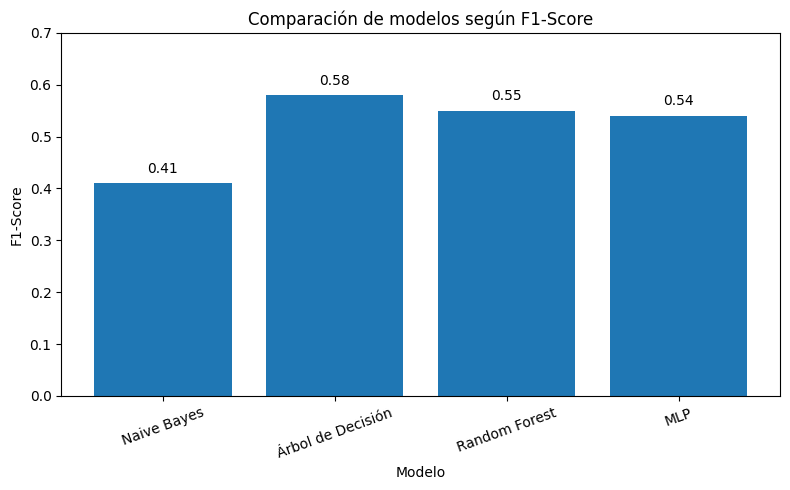

In [65]:
import pandas as pd
import matplotlib.pyplot as plt

# Datos de resultados de clasificación
resultados_modelos = pd.DataFrame({
    "Modelo": ["Naive Bayes", "Árbol de Decisión", "Random Forest", "MLP"],
    "Accuracy": [0.75, 0.91, 0.91, 0.90],
    "F1-Score": [0.41, 0.58, 0.55, 0.54]
})

# Mostrar tabla
display(resultados_modelos)

# Gráfico comparativo F1-Score
plt.figure(figsize=(8,5))
plt.bar(resultados_modelos["Modelo"], resultados_modelos["F1-Score"])

plt.title("Comparación de modelos según F1-Score")
plt.xlabel("Modelo")
plt.ylabel("F1-Score")
plt.ylim(0, 0.7)

# Agregar valores sobre las barras
for i, valor in enumerate(resultados_modelos["F1-Score"]):
    plt.text(i, valor + 0.02, f"{valor:.2f}", ha="center")

plt.xticks(rotation=20)
plt.tight_layout()
plt.savefig("comparacion_f1_score.png", dpi=300)
plt.show()

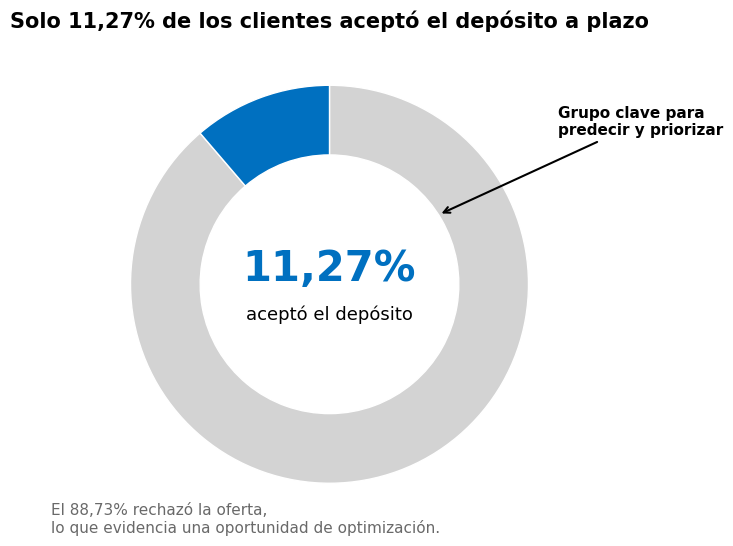

In [66]:
import matplotlib.pyplot as plt

# Datos
labels = ["No aceptó", "Aceptó"]
valores = [88.73, 11.27]
colores = ["lightgray", "#0070C0"]

fig, ax = plt.subplots(figsize=(7,7))

# Gráfico donut
wedges, texts = ax.pie(
    valores,
    colors=colores,
    startangle=90,
    counterclock=False,
    wedgeprops=dict(width=0.35, edgecolor="white")
)

# Texto central
ax.text(
    0, 0.08,
    "11,27%",
    ha="center",
    va="center",
    fontsize=30,
    fontweight="bold",
    color="#0070C0"
)

ax.text(
    0, -0.15,
    "aceptó el depósito",
    ha="center",
    va="center",
    fontsize=13
)

# Anotaciones
ax.annotate(
    "Grupo clave para\npredecir y priorizar",
    xy=(0.55, 0.35),
    xytext=(1.15, 0.75),
    arrowprops=dict(arrowstyle="->", lw=1.5),
    fontsize=11,
    fontweight="bold"
)

ax.text(
    -1.4, -1.25,
    "El 88,73% rechazó la oferta,\nlo que evidencia una oportunidad de optimización.",
    fontsize=11,
    color="dimgray"
)

ax.set_title(
    "Solo 11,27% de los clientes aceptó el depósito a plazo",
    fontsize=15,
    fontweight="bold"
)

plt.tight_layout()
plt.savefig("donut_aceptacion_storytelling.png", dpi=300, bbox_inches="tight")
plt.show()

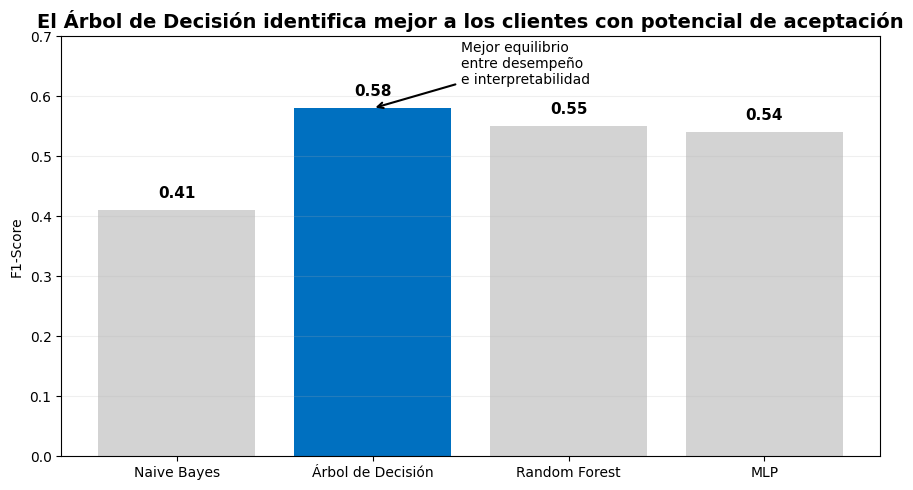

In [67]:
import pandas as pd
import matplotlib.pyplot as plt

resultados_modelos = pd.DataFrame({
    "Modelo": ["Naive Bayes", "Árbol de Decisión", "Random Forest", "MLP"],
    "F1-Score": [0.41, 0.58, 0.55, 0.54]
})

colores = ["lightgray", "#0070C0", "lightgray", "lightgray"]

plt.figure(figsize=(9,5))

barras = plt.bar(
    resultados_modelos["Modelo"],
    resultados_modelos["F1-Score"],
    color=colores
)

plt.title(
    "El Árbol de Decisión identifica mejor a los clientes con potencial de aceptación",
    fontsize=14,
    fontweight="bold"
)

plt.ylabel("F1-Score")
plt.ylim(0, 0.70)

for barra, valor in zip(barras, resultados_modelos["F1-Score"]):
    plt.text(
        barra.get_x() + barra.get_width()/2,
        valor + 0.02,
        f"{valor:.2f}",
        ha="center",
        fontsize=11,
        fontweight="bold"
    )

plt.annotate(
    "Mejor equilibrio\nentre desempeño\ne interpretabilidad",
    xy=(1, 0.58),
    xytext=(1.45, 0.62),  # aquí se bajó la frase
    arrowprops=dict(arrowstyle="->", lw=1.5),
    fontsize=10
)

plt.grid(axis="y", alpha=0.2)
plt.xlabel("")
plt.xticks(rotation=0)
plt.tight_layout()

plt.savefig("grafico_f1_storytelling.png", dpi=300, bbox_inches="tight")
plt.show()

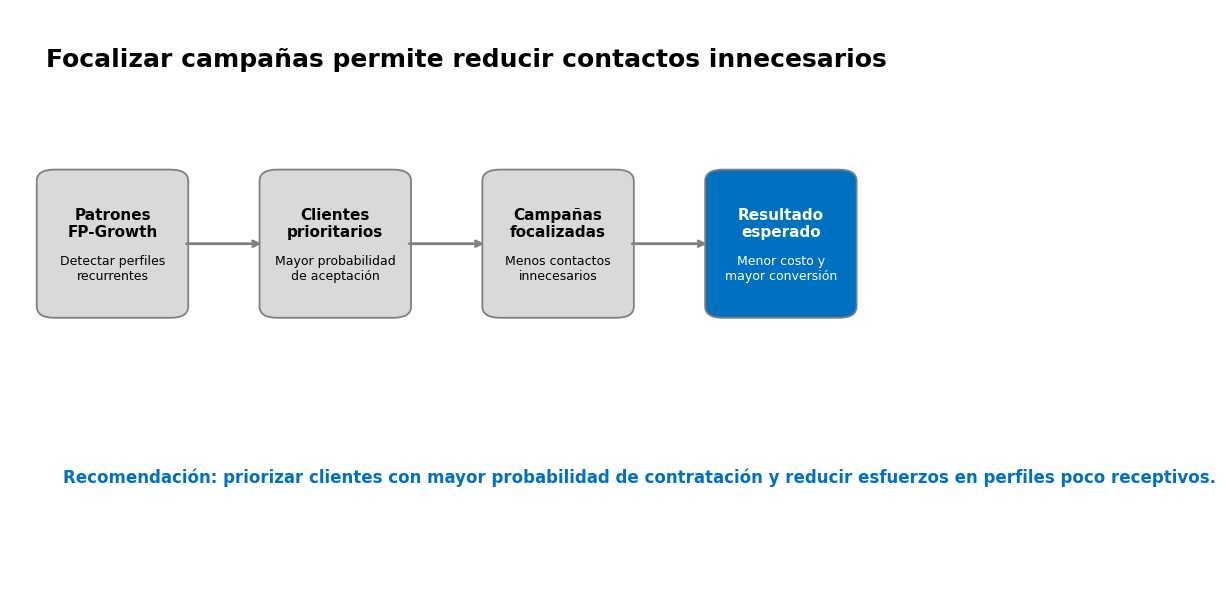

In [68]:
import matplotlib.pyplot as plt
from matplotlib.patches import FancyBboxPatch

fig, ax = plt.subplots(figsize=(12, 6))
ax.axis("off")

ax.text(
    0.04, 0.90,
    "Focalizar campañas permite reducir contactos innecesarios",
    fontsize=18,
    fontweight="bold",
    ha="left"
)

items = [
    ("Patrones\nFP-Growth", "Detectar perfiles\nrecurrentes"),
    ("Clientes\nprioritarios", "Mayor probabilidad\nde aceptación"),
    ("Campañas\nfocalizadas", "Menos contactos\ninnecesarios"),
    ("Resultado\nesperado", "Menor costo y\nmayor conversión")
]

# Más separación horizontal
x_pos = [0.05, 0.30, 0.55, 0.80]
y = 0.48
ancho = 0.13

for i, (titulo, texto) in enumerate(items):
    color = "#0070C0" if i == 3 else "#D9D9D9"
    txt_color = "white" if i == 3 else "black"
    
    rect = FancyBboxPatch(
        (x_pos[i], y), ancho, 0.22,
        boxstyle="round,pad=0.02",
        linewidth=1.3,
        edgecolor="gray",
        facecolor=color
    )
    ax.add_patch(rect)

    ax.text(
        x_pos[i] + ancho/2, y + 0.145,
        titulo,
        ha="center",
        va="center",
        fontsize=11,
        fontweight="bold",
        color=txt_color
    )

    ax.text(
        x_pos[i] + ancho/2, y + 0.065,
        texto,
        ha="center",
        va="center",
        fontsize=9,
        color=txt_color
    )

    if i < 3:
        ax.annotate(
            "",
            xy=(x_pos[i+1] - 0.015, y + 0.11),
            xytext=(x_pos[i] + ancho + 0.015, y + 0.11),
            arrowprops=dict(arrowstyle="->", lw=2, color="gray")
        )

ax.text(
    0.06, 0.17,
    "Recomendación: priorizar clientes con mayor probabilidad de contratación y reducir esfuerzos en perfiles poco receptivos.",
    fontsize=12,
    fontweight="bold",
    color="#0070C0"
)

plt.tight_layout()
plt.savefig("diapositiva3_storytelling_flechas_largas.png", dpi=300, bbox_inches="tight")
plt.show()

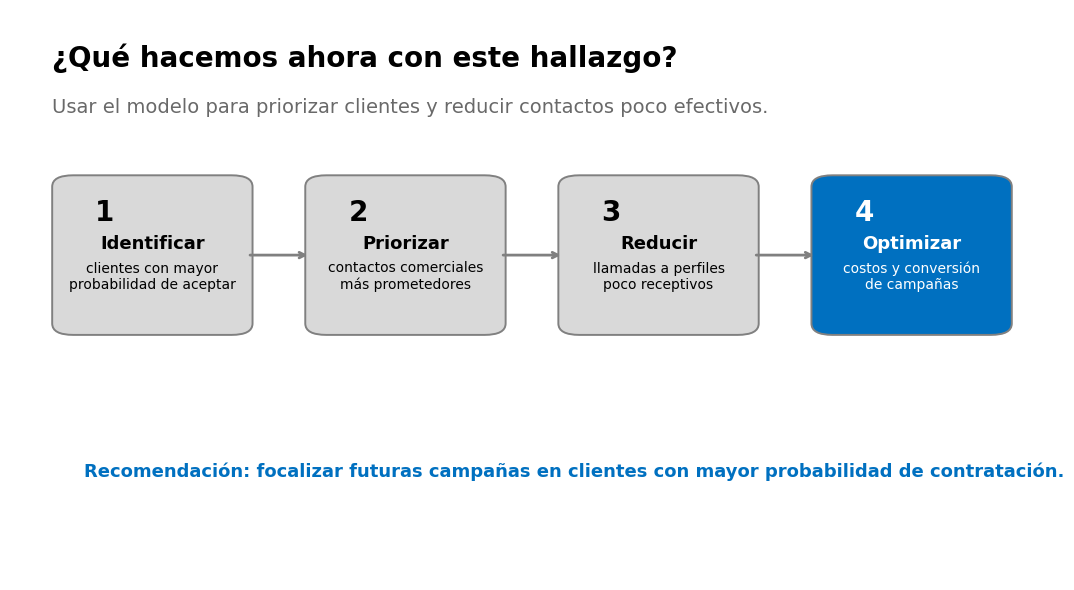

In [69]:
import matplotlib.pyplot as plt
from matplotlib.patches import FancyBboxPatch

fig, ax = plt.subplots(figsize=(12, 6))
ax.axis("off")

# Título tipo conclusión/acción
ax.text(
    0.04, 0.90,
    "¿Qué hacemos ahora con este hallazgo?",
    fontsize=20,
    fontweight="bold",
    ha="left"
)

ax.text(
    0.04, 0.82,
    "Usar el modelo para priorizar clientes y reducir contactos poco efectivos.",
    fontsize=14,
    color="dimgray",
    ha="left"
)

# Flujo de acción
items = [
    ("1", "Identificar", "clientes con mayor\nprobabilidad de aceptar"),
    ("2", "Priorizar", "contactos comerciales\nmás prometedores"),
    ("3", "Reducir", "llamadas a perfiles\npoco receptivos"),
    ("4", "Optimizar", "costos y conversión\nde campañas")
]

x_pos = [0.06, 0.30, 0.54, 0.78]
y = 0.45
ancho = 0.15
alto = 0.24

for i, (num, titulo, texto) in enumerate(items):
    color = "#0070C0" if i == 3 else "#D9D9D9"
    txt_color = "white" if i == 3 else "black"

    rect = FancyBboxPatch(
        (x_pos[i], y), ancho, alto,
        boxstyle="round,pad=0.02",
        linewidth=1.4,
        edgecolor="gray",
        facecolor=color
    )
    ax.add_patch(rect)

    ax.text(
        x_pos[i] + 0.03, y + 0.18,
        num,
        fontsize=20,
        fontweight="bold",
        color=txt_color,
        ha="center"
    )

    ax.text(
        x_pos[i] + ancho/2, y + 0.13,
        titulo,
        ha="center",
        fontsize=13,
        fontweight="bold",
        color=txt_color
    )

    ax.text(
        x_pos[i] + ancho/2, y + 0.06,
        texto,
        ha="center",
        fontsize=10,
        color=txt_color
    )

    if i < 3:
        ax.annotate(
            "",
            xy=(x_pos[i+1] - 0.015, y + alto/2),
            xytext=(x_pos[i] + ancho + 0.015, y + alto/2),
            arrowprops=dict(arrowstyle="->", lw=2, color="gray")
        )

# Recomendación final
ax.text(
    0.07, 0.18,
    "Recomendación: focalizar futuras campañas en clientes con mayor probabilidad de contratación.",
    fontsize=13,
    fontweight="bold",
    color="#0070C0"
)

plt.tight_layout()
plt.savefig("accion_final_bank_marketing.png", dpi=300, bbox_inches="tight")
plt.show()

In [70]:
import joblib

joblib.dump(tree, "modelo_arbol.pkl")
joblib.dump(X.columns.tolist(), "columnas_modelo.pkl")

['columnas_modelo.pkl']